In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.special import factorial
from scipy.stats import binned_statistic, binned_statistic_2d
from matplotlib.ticker import ScalarFormatter
import sys

In [2]:
sys.path.append(r"C:\Users\xylin\Documents\Researches\multiphonon-direct-detection\StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

## Script: modified StructureFactor1D class

The StructureFactor1D class uses a binned density of states approximation (see the description of the .py file), so as not to track the individual delta functions for efficiency.

However, since we are working on 2 phonons, we use the exact results (track all delta function and omega) to see the structure of the solutions better. 

In [3]:
class sfactor_plot2phonons(StructureFactor1D):
# compute the structure factor without any approximations

    def _s_diag_init(self):
        '''
        Get integrated diagonal s factor of order 1
        '''
        DWfactor =  np.exp(- 2 * self._DebyeWallerConst()) 
        s_values = 2 * np.pi / self.volume * self.nLattice * DWfactor * self.couplingConst**2 *  (self.q_value**2 /(2*self.mass*self.nLattice)) / self.omegaList
        return s_values

    def _calc_s_diag_rec(self,s_values):
        '''
        Helper function. 
        Use the recursive relation to calculate the structure factor of nPhonon-th order
        --------returns--------
        newS: (len(omegaList)^2,) array
        '''
        newIntS = (self.q_value**2 /(2*self.mass*self.nLattice))/2 * s_values[:, np.newaxis] / self.omegaList 
        return newIntS.T.flatten()


    def _c_offdiag_init(self,): # l' minus l
        '''
        Calculate the first c_ll' of the recursive relation. 
        currIntC_offdiag: 2d array with shape (# of nu, # of (l-l'))
        '''
        DWfactor =  np.exp(- 2 * self._DebyeWallerConst()) 
        offdiag_factor = np.exp(1j*(self.q_value*self.latticeConst-2*np.pi* self.nuList/self.nLattice)* self.l_diff) 
        c_values =  2 * np.pi / self.volume * DWfactor *  (self.q_value**2 /(2*self.mass*self.nLattice)) * offdiag_factor/ self.omegaList[:,np.newaxis]
        return c_values
    
    def _calc_c_offdiag_rec(self,c_values):
        '''
        Helper function. 
        Use the recursive relation to calculate the structure factor of nPhonon-th order
        --------returns--------
        newS: (len(omegaList)^2, # of (l-l')) array
        '''
        exp_factor = np.exp(-2j*np.pi*self.nuList*self.l_diff/self.nLattice)
        rec_factor = exp_factor/self.omegaList[:, np.newaxis]
        newIntC = (self.q_value**2 /(2*self.mass*self.nLattice))/2 * rec_factor[:, np.newaxis, :]*c_values
        return newIntC.reshape(-1,self.l_diff.shape[0])
    
    def calc_s_from_c(self, c_values):
        '''
        Helper function. Sum C over all l and l' to get S.  
        '''
        mult = (self.nLattice - self.l_diff)*np.real(c_values)
        sfactor_sum = 2* (self.couplingConst**2) * np.sum(mult, axis=1)
        return sfactor_sum

dispersion: $\omega_\nu = 2\omega_0 \sin \frac{k_\nu a}{2}$, $k_\nu = \frac{2\pi \nu}{Na}$

=> $ka = 2 \arcsin \frac {\omega}{2\omega_0}$

peaks should be at $qa = k_1 a + k_2 a$ up to integer multiples of $2\pi$, so $k_2a = qa - k_1a-\text{integer} \cdot 2\pi$

The range of $\omega_1+\omega_2$

$\omega_2 = 2\omega_0\sin\frac{qa-2\arcsin\frac{\omega_1}{2\omega_0}}{2} =  2\omega_0\big(\sin\frac{qa}{2}\cos(\arcsin\frac{\omega_1}{2\omega_0})  - \cos\frac{qa}{2}\sin(\arcsin\frac{\omega_1}{2\omega_0}) \big) $



$2\omega_0\big(\sin\frac{qa}{2}\sqrt{1-\frac{\omega_1^2}{4\omega_0^2}}  - \cos\frac{qa}{2}\frac{\omega_1}{2\omega_0} \big) $

compare $\omega_2$ with 1 phonon 

In [4]:
multplier = 1.5
q_value  = multplier*np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)
nLattice = 200

plottest = sfactor_plot2phonons(nLattice = nLattice,q_value=q_value, couplingConst=28,)
s_diag = plottest._calc_s_diag_rec(plottest._s_diag_init())
c_values = plottest._calc_c_offdiag_rec(plottest._c_offdiag_init())
s_offdiag = plottest.calc_s_from_c(c_values)

s_2phonons = s_diag + s_offdiag

omegax, omegay = np.meshgrid(plottest.omegaList, plottest.omegaList)
s_2phonons_binned, xedges, yedges, _  = binned_statistic_2d(omegax.flatten(), omegay.flatten(),s_2phonons,
                                                            statistic='sum', bins = [50, 50], range=[[0, 20e-6],[0,20e-6]])

<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
C:\Users\xylin\AppData\Local\Temp\ipykernel_25284\355910598.py:6: SyntaxWarning: invalid escape sequence '\o'
  cbar.ax.set_ylabel('$S(\omega,q)$', )
C:\Users\xylin\AppData\Local\Temp\ipykernel_25284\355910598.py:8: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Phonon 1 energy $\omega_1$ [meV]')
C:\Users\xylin\AppData\Local\Temp\ipykernel_25284\355910598.py:9: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Phonon 2 energy $\omega_2$ [meV]')


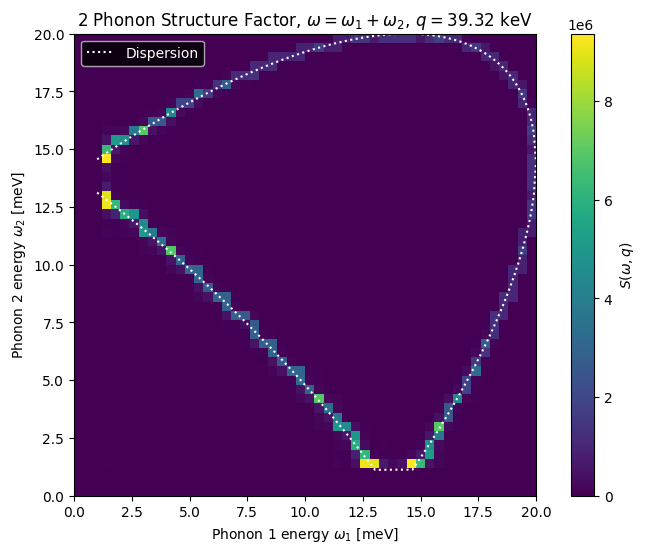

In [5]:
fig = plt.figure(figsize = (9,6))
ax1=plt.subplot(111)
xlist, ylist = np.meshgrid(xedges, yedges)
plot1 = ax1.pcolormesh(xlist*1e6,ylist*1e6,s_2phonons_binned/(xedges[1]-xedges[0]))
cbar = plt.colorbar(plot1,ax=ax1,)
cbar.ax.set_ylabel('$S(\omega,q)$', )
ax1.set_aspect('equal')
plt.xlabel('Phonon 1 energy $\omega_1$ [meV]')
plt.ylabel('Phonon 2 energy $\omega_2$ [meV]')
txt = r'$\omega = \omega_1+\omega_2,\,q = $'
plt.title(f'2 Phonon Structure Factor, {txt}{q_value:.2f} keV')

x = np.linspace(1e-6, 20e-6, 200) # 1 meV to 20 meV because of the low frequency cutoff
ka = 2*np.arcsin(x/(2*plottest.omegaNaught))
# apparently the int multiplier doesn't change the result since sin is periodical
def other_ka(int_multiplier=0): 
    return q_value*plottest.latticeConst + int_multiplier*(2*np.pi) - ka
def other_ka_minus(int_multiplier=0): 
    return q_value*plottest.latticeConst + int_multiplier*(2*np.pi) + ka

y1 = np.abs(2*plottest.omegaNaught*np.sin(other_ka()/2))
y2 = np.abs(2*plottest.omegaNaught*np.sin(other_ka_minus()/2))
mask1 = (y1>=1e-6) # enforce the low frequency cutoff
mask2 = (y2>=1e-6)

plt.plot(x[mask1]*1e6,np.abs(y1[mask1]*1e6), color='white', linestyle=':',label='Dispersion')
plt.plot(x[mask2]*1e6,np.abs(y2[mask2]*1e6), color='white', linestyle=':',)
plt.legend(facecolor='black',labelcolor='white')
plt.savefig(f"sfactor_2phonons_q{int(q_value)}_{nLattice}lattice", bbox_inches="tight")
plt.show()

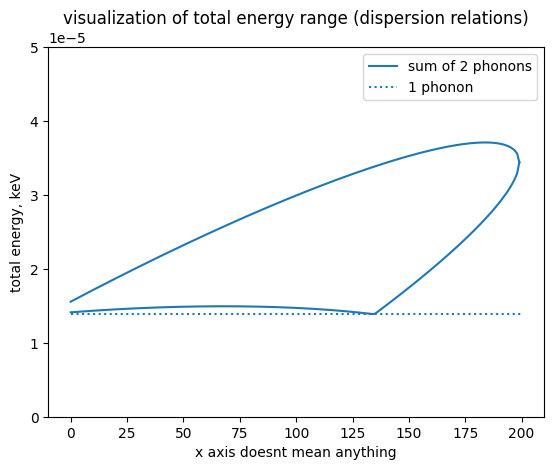

In [6]:
plt.plot(x+y1, color="tab:blue", label="sum of 2 phonons")
plt.plot(x+y2, color="tab:blue")
plt.hlines(np.abs(2*1e-5*np.sin(q_value*plottest.latticeConst/2)),0,200, linestyles=":",label="1 phonon")
plt.ylabel("total energy, keV")
plt.ylim(0, 50e-6)
plt.xlabel('x axis doesnt mean anything')
plt.title("visualization of total energy range (dispersion relations)")
plt.legend()